Data Exploration

folder name: images/dogs number of images: 1000


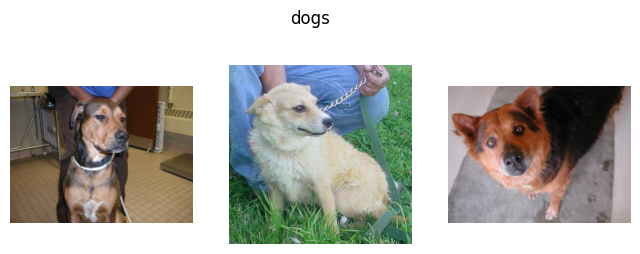

folder name: images/cats number of images: 1000


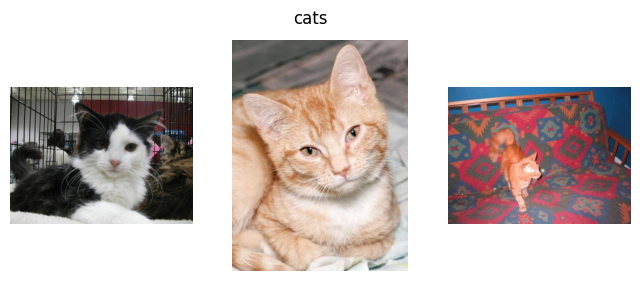

folder name: images/panda number of images: 1000


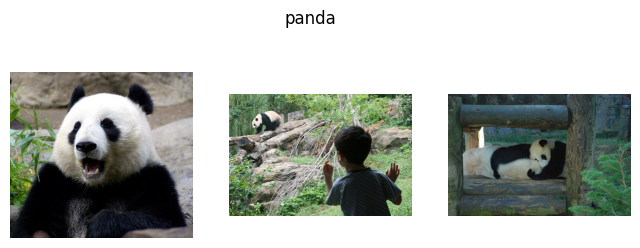

Total bad images 0 

sizes of images: [((500, 375), 514), ((500, 374), 246), ((499, 375), 218), ((500, 334), 85), ((375, 500), 49), ((500, 332), 34), ((500, 333), 29), ((374, 500), 26), ((375, 499), 20), ((499, 333), 14)] 



In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

data_dir = Path("images")
size = []
bad_images = []

for folder in data_dir.iterdir():
    if folder.is_dir():
        images = list(folder.glob("*.jpg"))
        print("folder name:", folder, "number of images:", len(images))
        for image_path in images:
            try:
                img = Image.open(image_path)
                size.append(img.size)
                img.verify()
            except Exception as e:
                bad_images.append(image_path)
                print("bad image",image_path, "|Error", e)

        plt.figure(figsize=(8,3))
        plt.suptitle(folder.name)
        plt_images = images[:3]
        for i, img_path in enumerate(plt_images):
            img = Image.open(img_path)
            plt.subplot(1, 3, i+1)
            plt.imshow(img)
            plt.axis("off")
        plt.show()

size_counts = Counter(size)
print("Total bad images", len(bad_images),"\n")
print("sizes of images:", size_counts.most_common(10),"\n" )




Check GreyScale Images vs RGB images

In [3]:
image_modes = []
grey_scale_images = []
for folder in data_dir.iterdir():
    
    image_paths = list(folder.glob("*.jpg"))
    
    for image_path in image_paths:
        img = Image.open(image_path)
        image_modes.append(img.mode)
        if img.mode == 'L':
            grey_scale_images.append(image_path)
    
image_modes_num = Counter(image_modes)
print(image_modes_num)
print(grey_scale_images)

Counter({'RGB': 2993, 'L': 7})
[PosixPath('images/panda/panda_00049.jpg'), PosixPath('images/panda/panda_00895.jpg'), PosixPath('images/panda/panda_00923.jpg'), PosixPath('images/panda/panda_00781.jpg'), PosixPath('images/panda/panda_00347.jpg'), PosixPath('images/panda/panda_00723.jpg'), PosixPath('images/panda/panda_00914.jpg')]


Split Images into different folders for traing, test and validate

In [4]:
import shutil
import random

output_dir = Path("images_split")
train = 0.7
val = 0.1
test = 0.2
random.seed(42)
for class_folder in data_dir.iterdir():
    if class_folder.is_dir():
        class_name = class_folder.name
        images_org = list(class_folder.glob("*.jpg"))
        random.shuffle(images_org)

        total_images = len(images_org)

        train_num = int(train * total_images)
        val_num = int(val * total_images)

        train_images = images_org[:train_num]
        val_images = images_org[train_num :train_num + val_num]
        test_images = images_org[train_num + val_num: ]

        for split_name , split_images in [
            ("train", train_images ),
            ("val",  val_images),
            ("test",test_images )]:

            split_dir = output_dir/ split_name/ class_folder.name
            split_dir.mkdir(parents = True, exist_ok = True)

            for image_path in split_images:
                shutil.copy(image_path, split_dir/image_path.name)

        print(class_name, class_folder)
        print("train length:", len(train_images))
        print("val length:", len(val_images))
        print("test length:", len(test_images),  "\n")

dogs images/dogs
train length: 700
val length: 100
test length: 200 

cats images/cats
train length: 700
val length: 100
test length: 200 

panda images/panda
train length: 700
val length: 100
test length: 200 



Check the split image dataset

In [5]:
split_dir_path  = Path("images_split")

for split in ["test", "train", "val"]:
     for class_folder in (split_dir_path/split).iterdir():
         class_images_sum = sum(1 for img in class_folder.glob("*.jpg"))
         print(split, class_folder,class_images_sum )



test images_split/test/dogs 200
test images_split/test/cats 200
test images_split/test/panda 200
train images_split/train/dogs 700
train images_split/train/cats 700
train images_split/train/panda 700
val images_split/val/dogs 100
val images_split/val/cats 100
val images_split/val/panda 100


In [6]:
import tensorflow as tf

2026-08-20 10:57:13.684289: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Create Training split Data

In [7]:
batch_siz = 32
img_size = (150,150)
train_data = tf.keras.utils.image_dataset_from_directory(
            "images_split/train",
            image_size = img_size,
            batch_size = batch_siz,
            color_mode = "rgb",
            shuffle = True
            )

print(train_data.class_names, "\n")
print(train_data)
print(train_data.element_spec)

Found 2100 files belonging to 3 classes.
['cats', 'dogs', 'panda'] 

<_BatchDataset element_spec=(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Create test Data Split

In [8]:
test_data = tf.keras.utils.image_dataset_from_directory(
            "images_split/test",
            image_size= img_size,
            color_mode = "rgb",
            batch_size = batch_siz     
            )
test_data.class_names

print(test_data.element_spec)

Found 600 files belonging to 3 classes.
(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


Create Validation test split

In [9]:
val_data = tf.keras.utils.image_dataset_from_directory(
            "images_split/val",
            image_size= img_size,
            color_mode = "rgb",
            batch_size = batch_siz     
            )
val_data.class_names
print(val_data.element_spec)

Found 300 files belonging to 3 classes.
(TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [10]:
for images, labels in train_data.take(1):
    print("Image shape:", images.shape)
    print("label shape:", labels.shape)
    print("lables for first 10:", labels[:10])
    print("Min pixel value:", images.numpy().min())
    print("Max pixel value:", images.numpy().max())


Image shape: (32, 150, 150, 3)
label shape: (32,)
lables for first 10: tf.Tensor([1 1 2 1 0 0 0 2 0 0], shape=(10,), dtype=int32)
Min pixel value: 0.0
Max pixel value: 255.0


2026-08-20 10:57:59.161410: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2100]
	 [[{{node Placeholder/_4}}]]
2026-08-20 10:57:59.161925: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2100]
	 [[{{node Placeholder/_4}}]]


Check images in train set in batch one

2026-08-20 10:58:03.321928: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2100]
	 [[{{node Placeholder/_4}}]]
2026-08-20 10:58:03.322362: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2100]
	 [[{{node Placeholder/_4}}]]


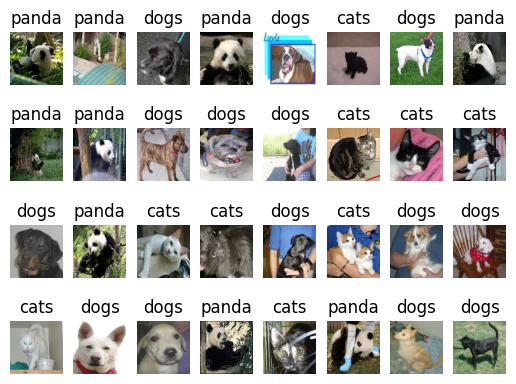

In [11]:
class_name = train_data.class_names
for images, labels in train_data.take(1):
    for i, image in enumerate(images):
        plt.subplot(4,8, i+1)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(class_name[labels[i]])
        plt.axis("off")
    plt.show()

Check the cat, dog and panda category per splt data set for test, train and validate

In [12]:
for data_set_name, data_set in [("train",train_data), ("test", test_data), ("val",val_data)]:
    label_counter = Counter()
    for images, label in data_set:
        label_counter.update(label.numpy())
    print(data_set_name, label_counter)

2026-08-20 10:58:11.288136: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2100]
	 [[{{node Placeholder/_4}}]]
2026-08-20 10:58:11.288558: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [2100]
	 [[{{node Placeholder/_4}}]]


train Counter({2: 700, 0: 700, 1: 700})


2026-08-20 10:58:12.005203: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [600]
	 [[{{node Placeholder/_0}}]]
2026-08-20 10:58:12.005618: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [600]
	 [[{{node Placeholder/_4}}]]


test Counter({1: 200, 0: 200, 2: 200})
val Counter({0: 100, 1: 100, 2: 100})


2026-08-20 10:58:12.244672: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [300]
	 [[{{node Placeholder/_4}}]]
2026-08-20 10:58:12.245088: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [300]
	 [[{{node Placeholder/_0}}]]


## Number of batches created  per split 

In [13]:
print("train_batches:", len(train_data))
print("test_batches:", len(test_data))
print("val_batches:", len(val_data))

train_batches: 66
test_batches: 19
val_batches: 10


In [14]:
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.layers import  Dense, Input, Conv2D, Conv1D, MaxPooling2D, GlobalMaxPooling2D, Rescaling, Dropout

## BaseLine model with two Conv2D layers eaxh with (3,3) filter and 2 Maxpooling Flattening is acheived by GlobalMaxPooling2D

In [15]:
image_input = Input(shape=(150,150,3), name = "image_input")
rescale  = Rescaling(1./255)(image_input)
cnn1 = Conv2D(32,(3,3), activation="relu")(rescale)
pooling_layer = MaxPooling2D((2,2))(cnn1)

cnn2 = Conv2D(32,(3,3), activation="relu")(pooling_layer)
pooling_layer2 = MaxPooling2D((2,2))(cnn2)

flatten = GlobalMaxPooling2D()(pooling_layer2)

connected_layer = Dense(128, activation="relu")(flatten)
output_layer = Dense(3, activation="softmax")(connected_layer)

In [16]:
model = Model(
    inputs = image_input,
    outputs = output_layer
)

In [17]:
model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [18]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 150, 150, 3)]     0         
                                                                 
 rescaling (Rescaling)       (None, 150, 150, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 72, 72, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 32)       0         
 2D)                                                         

In [19]:
history = model.fit(
    train_data,
    validation_data =  val_data,
    epochs = 30
)

Epoch 1/30


66/66 [==============================] - 13s 187ms/step - loss: 1.0081 - accuracy: 0.4719 - val_loss: 0.8630 - val_accuracy: 0.5567
Epoch 2/30
66/66 [==============================] - 12s 182ms/step - loss: 0.8057 - accuracy: 0.5686 - val_loss: 0.7701 - val_accuracy: 0.5667
Epoch 3/30
66/66 [==============================] - 12s 184ms/step - loss: 0.7318 - accuracy: 0.6167 - val_loss: 0.7104 - val_accuracy: 0.6233
Epoch 4/30
66/66 [==============================] - 12s 184ms/step - loss: 0.6995 - accuracy: 0.6290 - val_loss: 0.7648 - val_accuracy: 0.6033
Epoch 5/30
66/66 [==============================] - 12s 187ms/step - loss: 0.6822 - accuracy: 0.6524 - val_loss: 0.6840 - val_accuracy: 0.6400
Epoch 6/30
66/66 [==============================] - 12s 186ms/step - loss: 0.6469 - accuracy: 0.6671 - val_loss: 0.6757 - val_accuracy: 0.6133
Epoch 7/30
66/66 [==============================] - 12s 186ms/step - loss: 0.6579 - accuracy: 0.6571 - val_loss: 0.6583 - val_accuracy: 0.6967
Epoch 8/30

In [20]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Baseline :test loss:",test_loss,"test_accuracy", test_accuracy)

19/19 [==============================] - 1s 49ms/step - loss: 0.5796 - accuracy: 0.7383
Baseline :test loss: 0.5795705914497375 test_accuracy 0.7383333444595337


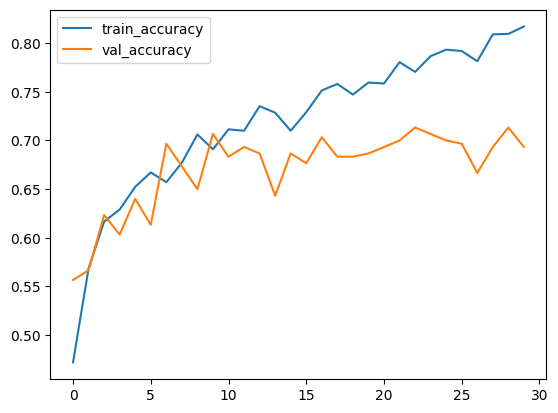

In [21]:
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

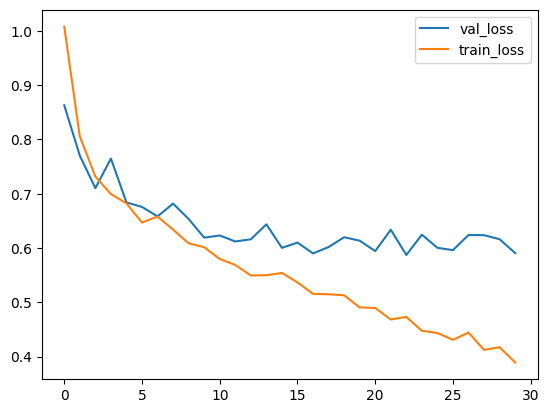

In [22]:
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["loss"], label="train_loss")
plt.legend()
plt.show()

## Confususion Matrix

In [23]:
import numpy as np
y_actual =[]
y_predict = []
for images, labels in test_data:
    predictions = model.predict(images)
    #print(predictions)
    prediction_act = np.argmax(predictions, axis=1)
    #print(prediction_act)
    y_actual.extend(labels.numpy())
    y_predict.extend(prediction_act)

y_actual = np.array(y_actual)
y_predict = np.array(y_predict)

confusion_matrix = tf.math.confusion_matrix(y_actual, y_predict)
print(confusion_matrix.numpy())

1/1 [==============================] - 0s 107ms/step
[[119  67  14]
 [ 49 135  16]
 [  3   8 189]]


### Confusion Matrix Display

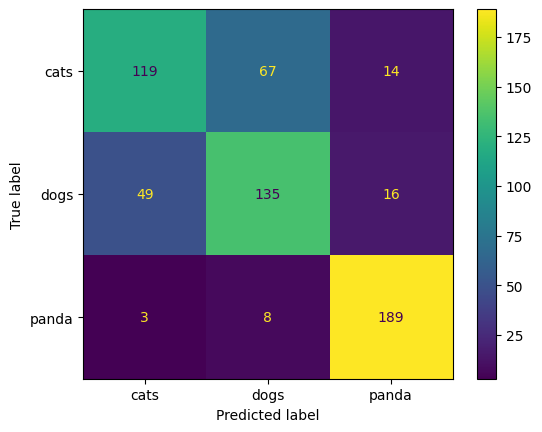

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
class_names = ["cats", "dogs", "panda"]

disp = ConfusionMatrixDisplay(
    confusion_matrix.numpy(),
    display_labels=class_name
)
disp.plot()
plt.show()

## Model with Augmentation

In [26]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomContrast

data_augmentation =  tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.08),
    RandomZoom(.10),
    RandomContrast(.10)
], name = "data_augmentation")


In [27]:
image_input = Input(shape=(150,150,3), name = "image_input")

augmented_data = data_augmentation(image_input)

rescale  = Rescaling(1./255)(augmented_data)
cnn1 = Conv2D(32,(3,3), activation="relu")(rescale)
pooling_layer = MaxPooling2D((2,2))(cnn1)

cnn2 = Conv2D(32,(3,3), activation="relu")(pooling_layer)
pooling_layer2 = MaxPooling2D((2,2))(cnn2)

flatten = GlobalMaxPooling2D()(pooling_layer2)

connected_layer = Dense(128, activation="relu")(flatten)
output_layer = Dense(3, activation="softmax")(connected_layer)

In [28]:
model2 = Model(
    inputs = image_input,
    outputs = output_layer
)

model2.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
model2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 150, 150, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 150, 150, 3)      0         
 al)                                                             
                                                                 
 rescaling_1 (Rescaling)     (None, 150, 150, 3)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 74, 74, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 32)        9248

In [29]:
history = model2.fit(
    train_data,
    validation_data =  val_data,
    epochs = 30
)

Epoch 1/30
66/66 [==============================] - 15s 212ms/step - loss: 1.0197 - accuracy: 0.4671 - val_loss: 0.8795 - val_accuracy: 0.5667
Epoch 2/30
66/66 [==============================] - 14s 209ms/step - loss: 0.8909 - accuracy: 0.5267 - val_loss: 0.8247 - val_accuracy: 0.5567
Epoch 3/30
66/66 [==============================] - 14s 209ms/step - loss: 0.8158 - accuracy: 0.5862 - val_loss: 0.7590 - val_accuracy: 0.5800
Epoch 4/30
66/66 [==============================] - 14s 209ms/step - loss: 0.7983 - accuracy: 0.5957 - val_loss: 0.7377 - val_accuracy: 0.6100
Epoch 5/30
66/66 [==============================] - 14s 210ms/step - loss: 0.7280 - accuracy: 0.6219 - val_loss: 1.0751 - val_accuracy: 0.5100
Epoch 6/30
66/66 [==============================] - 14s 208ms/step - loss: 0.6988 - accuracy: 0.6543 - val_loss: 0.7675 - val_accuracy: 0.6033
Epoch 7/30
66/66 [==============================] - 14s 207ms/step - loss: 0.6856 - accuracy: 0.6481 - val_loss: 0.6867 - val_accuracy: 0.6100

In [30]:
test_loss, test_accuracy = model2.evaluate(test_data)
print("test loss Augmented data line:",test_loss,"test_accuracy", test_accuracy)

19/19 [==============================] - 1s 46ms/step - loss: 0.6764 - accuracy: 0.7283
test loss Augmented data line: 0.676391065120697 test_accuracy 0.7283333539962769


## VGG Style model + Data Augmentation 

In [36]:

image_input = Input(shape=(150,150,3), name = "image_input")
## Data Augmentation
#augmented_data = data_augmentation(image_input)
##Rescaling
x  = Rescaling(1./255)(image_input)
##VVG block 1
x = Conv2D(32,(3,3), activation="relu", padding = "same")(x)
x = Conv2D(32,(3,3), activation="relu",padding = "same")(x)
x = MaxPooling2D((2,2))(x)

##VVG block 2
x = Conv2D(64,(3,3), activation="relu", padding = "same")(x)
x = Conv2D(64,(3,3), activation="relu",padding = "same")(x)
x = MaxPooling2D((2,2))(x)

# ##VVG block 3 
## Din not train well with this block so commented 
# x = Conv2D(128,(3,3), activation="relu", padding = "same")(x)
# x = Conv2D(128,(3,3), activation="relu",padding = "same")(x)
# x = MaxPooling2D((2,2))(x)
# x = Dropout(0.25)(x)


flatten = GlobalMaxPooling2D()(x)

x = Dense(128, activation="relu")(flatten)
output_layer = Dense(3, activation="softmax")(x)

In [38]:
model_vgg = Model(
    inputs = image_input,
    outputs = output_layer
)

model_vgg.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)
model_vgg.summary()
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = "val_accuracy",
    patience = 4,
    mode = max,
    restore_best_weights = True
)

Model: "model_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image_input (InputLayer)    [(None, 150, 150, 3)]     0         
                                                                 
 rescaling_3 (Rescaling)     (None, 150, 150, 3)       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 150, 150, 32)      896       
                                                                 
 conv2d_9 (Conv2D)           (None, 150, 150, 32)      9248      
                                                                 
 max_pooling2d_6 (MaxPooling  (None, 75, 75, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 75, 75, 64)        18496     
                                                           

In [39]:
history = model_vgg.fit(
    train_data,
    validation_data =  val_data,
    epochs = 25,
    callbacks =[early_stop]
)

Epoch 1/25
66/66 [==============================] - 52s 774ms/step - loss: 0.9685 - accuracy: 0.4824 - val_loss: 0.8823 - val_accuracy: 0.5367
Epoch 2/25
66/66 [==============================] - 52s 784ms/step - loss: 0.8083 - accuracy: 0.5819 - val_loss: 0.9291 - val_accuracy: 0.5367
Epoch 3/25
66/66 [==============================] - 51s 778ms/step - loss: 0.7790 - accuracy: 0.5848 - val_loss: 0.7950 - val_accuracy: 0.6100
Epoch 4/25
66/66 [==============================] - 52s 782ms/step - loss: 0.7340 - accuracy: 0.6171 - val_loss: 0.7825 - val_accuracy: 0.6133
Epoch 5/25
66/66 [==============================] - 52s 784ms/step - loss: 0.7190 - accuracy: 0.6243 - val_loss: 0.7683 - val_accuracy: 0.6200
Epoch 6/25
66/66 [==============================] - 52s 790ms/step - loss: 0.6818 - accuracy: 0.6343 - val_loss: 0.7492 - val_accuracy: 0.6367
Epoch 7/25
66/66 [==============================] - 52s 786ms/step - loss: 0.6570 - accuracy: 0.6686 - val_loss: 0.7840 - val_accuracy: 0.6233

In [40]:
test_loss, test_accuracy = model_vgg.evaluate(test_data)
print("test loss:",test_loss,"test_accuracy", test_accuracy)

19/19 [==============================] - 2s 122ms/step - loss: 0.6955 - accuracy: 0.6833
test loss: 0.6954647898674011 test_accuracy 0.6833333373069763


## CNN with RSMProp as optimizer

In [41]:
image_input = Input(shape=(150,150,3), name = "image_input")
rescale  = Rescaling(1./255)(image_input)
cnn1 = Conv2D(32,(3,3), activation="relu")(rescale)
pooling_layer = MaxPooling2D((2,2))(cnn1)

cnn2 = Conv2D(32,(3,3), activation="relu")(pooling_layer)
pooling_layer2 = MaxPooling2D((2,2))(cnn2)

flatten = GlobalMaxPooling2D()(pooling_layer2)

connected_layer = Dense(128, activation="relu")(flatten)
output_layer = Dense(3, activation="softmax")(connected_layer)

model_rsm = Model(
    inputs = image_input,
    outputs = output_layer
)

model_rsm.compile(
    optimizer = "rmsprop",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

history = model_rsm.fit(
    train_data,
    validation_data =  val_data,
    epochs = 30
)

Epoch 1/30
66/66 [==============================] - 14s 206ms/step - loss: 0.9862 - accuracy: 0.4919 - val_loss: 0.9072 - val_accuracy: 0.5233
Epoch 2/30
66/66 [==============================] - 13s 188ms/step - loss: 0.8324 - accuracy: 0.5814 - val_loss: 0.7887 - val_accuracy: 0.6367
Epoch 3/30
66/66 [==============================] - 13s 190ms/step - loss: 0.7865 - accuracy: 0.6052 - val_loss: 0.7594 - val_accuracy: 0.6200
Epoch 4/30
66/66 [==============================] - 13s 190ms/step - loss: 0.7605 - accuracy: 0.6214 - val_loss: 0.7454 - val_accuracy: 0.6000
Epoch 5/30
66/66 [==============================] - 12s 188ms/step - loss: 0.7338 - accuracy: 0.6305 - val_loss: 0.7505 - val_accuracy: 0.6267
Epoch 6/30
66/66 [==============================] - 13s 192ms/step - loss: 0.7138 - accuracy: 0.6538 - val_loss: 0.7915 - val_accuracy: 0.5733
Epoch 7/30
66/66 [==============================] - 13s 196ms/step - loss: 0.6959 - accuracy: 0.6571 - val_loss: 0.7714 - val_accuracy: 0.6133

In [43]:
test_loss, test_accuracy = model_rsm.evaluate(test_data)
print("test rsmprop loss:",test_loss,"test_accuracy", test_accuracy)

19/19 [==============================] - 1s 47ms/step - loss: 0.5909 - accuracy: 0.7283
test rsmprop loss: 0.5908837914466858 test_accuracy 0.7283333539962769


Four models were compared: a baseline CNN using Adam, the same CNN with data augmentation, a VGG-style CNN with early stopping, and the baseline CNN using RMSprop. The baseline CNN with Adam achieved the best overall test performance, with a test accuracy of 73.83% and the lowest test loss of 0.5796. The CNN with RMSprop performed similarly with 72.83% test accuracy and a loss of 0.5909, while the model with data augmentation also achieved 72.83% accuracy but had a higher test loss of 0.6764. The VGG-style CNN produced the lowest test accuracy of 68.33% with a test loss of 0.6955. These results show that increasing model complexity or adding augmentation did not improve performance for this dataset and configuration. Therefore, the simpler baseline CNN with Adam was the most effective model among the approaches tested.